# Internações hospitalares: causas, custo e permanência

**Pergunta que este notebook responde:** por que as pessoas foram internadas
pelo SUS no estado, quanto tempo ficaram e quanto custou?

**Fonte:** SIH — Sistema de Informações Hospitalares, grupo `RD` (AIH reduzida:
uma linha por internação).
**Tempo estimado:** 4 a 6 minutos.

> ⚠️ **A cobertura do SIH é irregular.** No catálogo, cada estado costuma ter
> apenas alguns meses publicados por ano — e não são os mesmos entre estados.
> Por isso este notebook **descobre sozinho** um mês com dados, em vez de você
> ter que adivinhar.

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"     # sigla do estado
ANO = 2024

## Passo 1 — Descobrir quais meses existem

Aqui está a diferença deste notebook: em vez de pedir um mês fixo (que pode não
existir e devolver uma tabela vazia sem avisar), consultamos o catálogo e
listamos os meses realmente disponíveis do grupo `RD`.

In [4]:
from pysus import list_files

catalogo = list_files(dataset="sih", state=UF, year=ANO)

# O nome do arquivo é do tipo RDPR2408.parquet: grupo(2) + UF(2) + ano(2) + mês(2)
meses_rd = sorted(
    int(nome.split("\\")[-1][6:8])
    for nome in catalogo["name"]
    if nome.split("\\")[-1].startswith("RD")
)

print(f"Meses com internações (grupo RD) em {UF}/{ANO}: {meses_rd}")

if not meses_rd:
    print("⚠ Nenhum mês publicado para este ano. Tente o ano anterior.")
else:
    MES = meses_rd[-1]     # usamos o mês mais recente disponível
    print(f"→ Vamos usar {MES:02d}/{ANO}")

Meses com internações (grupo RD) em PR/2024: [8]
→ Vamos usar 08/2024


## Passo 2 — Baixar as internações

No SIH, **não** se passa o parâmetro `group` — fazer isso devolve zero linhas.
A biblioteca traz o grupo `RD` por padrão quando ele é o único disponível para
o recorte.

In [5]:
from pysus import sih

internacoes = sih(state=UF, year=ANO, month=MES, as_dataframe=True)

print(f"{len(internacoes):,} internações em {UF}, {MES:02d}/{ANO}")
print(f"{len(internacoes.columns)} colunas")

91,493 internações em PR, 08/2024
113 colunas


## Passo 3 — Principais causas de internação

O diagnóstico principal está em `DIAG_PRINC`, no formato CID-10.

In [6]:
import pandas as pd

top_causas = (
    internacoes["DIAG_PRINC"]
    .value_counts()
    .head(15)
    .rename_axis("CID-10")
    .reset_index(name="Internações")
)
top_causas["% do total"] = (top_causas["Internações"] / len(internacoes) * 100).round(2)
top_causas

,CID-10,Internações,% do total
0,J189,2740,2.99
1,O800,2683,2.93
2,Z302,1857,2.03
3,O820,1743,1.91
4,I200,1444,1.58
5,I64,1353,1.48
6,J180,1222,1.34
7,N390,1102,1.20
8,I500,1035,1.13
9,K409,928,1.01


### Agrupando por capítulo da CID-10

O primeiro caractere do código indica o grande grupo de causas — uma leitura
mais útil para gestão.

In [7]:
CAPITULOS = {
    "A": "Infecciosas e parasitárias", "B": "Infecciosas e parasitárias",
    "C": "Neoplasias", "D": "Neoplasias e doenças do sangue",
    "E": "Endócrinas e metabólicas", "F": "Transtornos mentais",
    "G": "Sistema nervoso", "H": "Olhos e ouvidos",
    "I": "Aparelho circulatório", "J": "Aparelho respiratório",
    "K": "Aparelho digestivo", "L": "Pele", "M": "Sistema osteomuscular",
    "N": "Aparelho geniturinário", "O": "Gravidez, parto e puerpério",
    "P": "Período perinatal", "Q": "Malformações congênitas",
    "R": "Sintomas mal definidos", "S": "Lesões e traumatismos",
    "T": "Lesões e envenenamentos", "Z": "Contatos com serviços de saúde",
}

internacoes["capitulo"] = (
    internacoes["DIAG_PRINC"].str[0].map(CAPITULOS).fillna("Outros")
)

por_capitulo = (
    internacoes["capitulo"].value_counts()
    .rename_axis("Grupo de causas")
    .reset_index(name="Internações")
)
por_capitulo["%"] = (por_capitulo["Internações"] / len(internacoes) * 100).round(1)
por_capitulo.head(10)

,Grupo de causas,Internações,%
0,Aparelho respiratório,10706,11.7
1,Aparelho circulatório,10648,11.6
2,Aparelho digestivo,10201,11.1
3,"Gravidez, parto e puerpério",9542,10.4
4,Neoplasias,7619,8.3
5,Lesões e traumatismos,7261,7.9
6,Aparelho geniturinário,6591,7.2
7,Infecciosas e parasitárias,4766,5.2
8,Lesões e envenenamentos,3044,3.3
9,Transtornos mentais,2961,3.2


## Passo 4 — Em gráfico

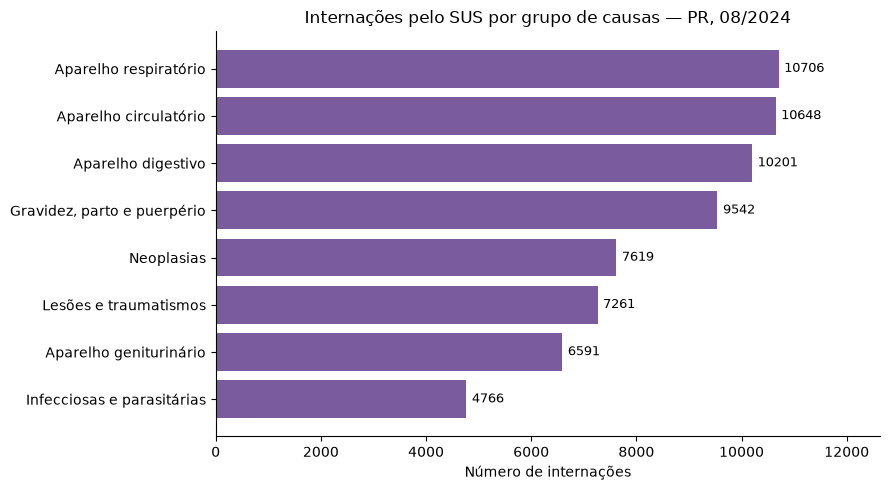

In [8]:
import matplotlib.pyplot as plt

grafico = por_capitulo.head(8).sort_values("Internações")

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(grafico["Grupo de causas"], grafico["Internações"], color="#7a5c9e")
ax.bar_label(barras, padding=4, fontsize=9)

ax.set_title(f"Internações pelo SUS por grupo de causas — {UF}, {MES:02d}/{ANO}",
             fontsize=12)
ax.set_xlabel("Número de internações")
ax.set_xlim(0, grafico["Internações"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 5 — Custo e tempo de permanência

Duas colunas muito usadas em gestão hospitalar:

- `VAL_TOT` — valor total da internação (em reais)
- `DIAS_PERM` — dias de permanência

In [9]:
valor = pd.to_numeric(internacoes["VAL_TOT"], errors="coerce")
dias = pd.to_numeric(internacoes["DIAS_PERM"], errors="coerce")

print(f"Valor total pago no mês:      R$ {valor.sum():>15,.2f}")
print(f"Valor médio por internação:   R$ {valor.mean():>15,.2f}")
print(f"Valor mediano:                R$ {valor.median():>15,.2f}")
print()
print(f"Permanência média:            {dias.mean():>10.1f} dias")
print(f"Permanência mediana:          {dias.median():>10.1f} dias")

Valor total pago no mês:      R$  177,631,574.14


Valor médio por internação:   R$        1,941.48
Valor mediano:                R$          720.51

Permanência média:                   4.1 dias
Permanência mediana:                 2.0 dias


> A média de custo costuma ser bem maior que a mediana: poucas internações de
> alta complexidade puxam o valor para cima. Em relatórios, informar as duas
> evita conclusões distorcidas.

## Passo 6 — Óbitos hospitalares

A coluna `MORTE` indica se a internação terminou em óbito (`1`) ou não (`0`).

In [10]:
mortes = pd.to_numeric(internacoes["MORTE"], errors="coerce").fillna(0)

print(f"Internações no período: {len(internacoes):,}")
print(f"Óbitos hospitalares:    {int(mortes.sum()):,}")
print(f"Letalidade hospitalar:  {mortes.mean():.2%}")

Internações no período: 91,493
Óbitos hospitalares:    3,990
Letalidade hospitalar:  4.36%


## Como adaptar

- **Outro estado ou ano:** mude `UF` e `ANO` — o notebook encontra sozinho um
  mês com dados.
- **Outro mês:** escolha um valor da lista `meses_rd` impressa no Passo 1.
- **Um município:** filtre `MUNIC_RES` (código IBGE de residência).
- **Uma causa específica:** filtre `DIAG_PRINC`, por exemplo
  `internacoes[internacoes["DIAG_PRINC"].str.startswith("J18")]` para pneumonia.
- **Internações de urgência:** a coluna `CAR_INT` separa eletivas de urgências.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*